In [45]:
# CHẠY CELL NÀY ĐẦU TIÊN
!pip install pygame numpy imageio[ffmpeg] matplotlib

import os
# Khởi chạy Pygame ở chế độ không màn hình (để chạy trên Google Colab)
os.environ["SDL_VIDEODRIVER"] = "dummy"

import pygame
import random
import numpy as np
import imageio
import math
import matplotlib.pyplot as plt
from IPython.display import Image, display

print("Cài đặt thư viện và thiết lập môi trường ảo thành công!")

Cài đặt thư viện và thiết lập môi trường ảo thành công!


In [46]:
# ----------------- CẤU HÌNH GIAO DIỆN NGANG -----------------
SCREEN_WIDTH = 1000   # Chiều dài màn hình ngang (tăng để đường dài hơn)
SCREEN_HEIGHT = 400  # Chiều cao màn hình
ROAD_HEIGHT = 160    # Chiều rộng của đường nhựa (2 làn)

# Màu sắc chuẩn theo hình mẫu của bạn
GREEN_GRASS = (34, 139, 34)    # Màu nền cỏ xanh lá
GRAY_ROAD = (50, 50, 50)       # Màu đường nhựa xám
WHITE = (255, 255, 255)        # Vạch kẻ đường
BLUE_CAR = (0, 128, 255)       # Xe tự hành màu xanh dương
RED_HEAD = (255, 0, 0)         # Đầu xe màu đỏ (hướng sang phải)
FINISH_LINE_COLOR = (0, 150, 255) # Vạch đích màu xanh lam (như trong hình mẫu)

# ==================== CHỌN MAP ĐỂ CHẠY ====================
# MAP_ID = 1 : Đường thẳng nằm ngang
# MAP_ID = 2 : Đường cong hình Sin nằm ngang
MAP_ID = 1  # Sẽ được thay đổi trong hàm train_and_evaluate_map
# ==========================================================

def get_road_center_y(x):
    """Xác định vị trí tim đường theo trục Y tại mỗi điểm tọa độ X dọc màn hình"""
    base_center_y = SCREEN_HEIGHT // 2

    if MAP_ID == 1:
        return base_center_y  # Đường thẳng: Tim đường luôn nằm chính giữa chiều cao

    elif MAP_ID == 2:
        # Đường cong: Uốn lượn hình Sin mượt mà theo trục X
        return base_center_y + int(50 * math.sin(x * 0.015)) # Tần số sóng giữ nguyên

    return base_center_y

print(f"Đã thiết lập các hằng số giao diện và hàm get_road_center_y!")

Đã thiết lập các hằng số giao diện và hàm get_road_center_y!


🖼️ Ảnh môi trường khởi tạo cho MAP 1:


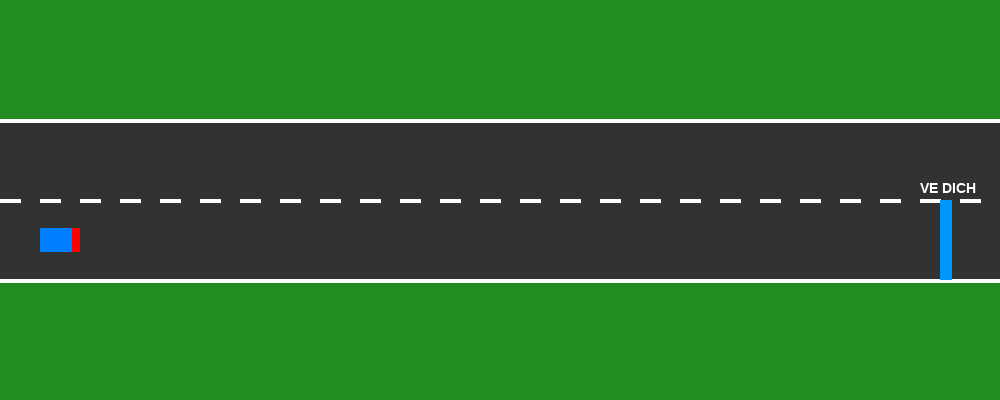


🖼️ Ảnh môi trường khởi tạo cho MAP 2:


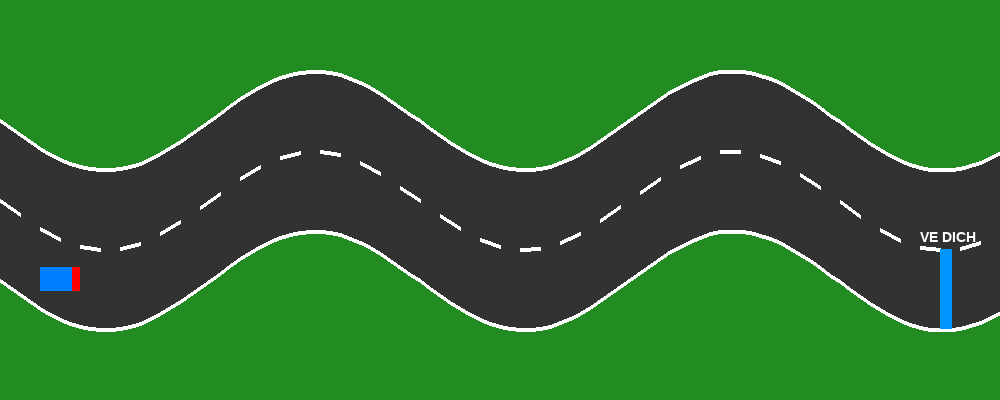

In [47]:
# Tạo và hiển thị ảnh môi trường khởi tạo cho Map 1
global MAP_ID
MAP_ID = 1 # Đặt lại MAP_ID cho Map 1
env_map1 = ColabCarEnv()
env_map1.reset()
env_map1.draw(virtual_screen)

view_map1 = pygame.surfarray.array3d(virtual_screen)
view_map1 = view_map1.transpose([1, 0, 2])

initial_env_filename_map1 = "initial_environment_map1.png"
imageio.imwrite(initial_env_filename_map1, view_map1)

print(f"🖼️ Ảnh môi trường khởi tạo cho MAP 1:")
display(Image(filename=initial_env_filename_map1, width=800))

# Tạo và hiển thị ảnh môi trường khởi tạo cho Map 2
MAP_ID = 2 # Đặt lại MAP_ID cho Map 2
env_map2 = ColabCarEnv()
env_map2.reset()
env_map2.draw(virtual_screen)

view_map2 = pygame.surfarray.array3d(virtual_screen)
view_map2 = view_map2.transpose([1, 0, 2])

initial_env_filename_map2 = "initial_environment_map2.png"
imageio.imwrite(initial_env_filename_map2, view_map2)

print(f"\n🖼️ Ảnh môi trường khởi tạo cho MAP 2:")
display(Image(filename=initial_env_filename_map2, width=800))


In [48]:
class ColabCarEnv:
    def __init__(self):
        self.car_width = 40
        self.car_height = 24
        self.goal_x = SCREEN_WIDTH - 60  # Vạch đích cố định ở phía bên phải màn hình, điều chỉnh theo SCREEN_WIDTH

    def reset(self):
        """Đặt xe ở phía bên trái màn hình chuẩn bị chạy sang phải"""
        self.x = 60  # Xuất phát từ trái

        # Đặt xe vào chính giữa làn phía dưới (làn xe đi theo quy định)
        start_road_center = get_road_center_y(self.x)
        self.y = start_road_center + ROAD_HEIGHT // 4

        self.is_crashed = False
        self.has_finished = False
        return self.get_state()

    def get_state(self):
        """Rời rạc hóa khoảng cách lệch tâm làn dưới thành 10 trạng thái (0-9)"""
        road_center = get_road_center_y(self.x)
        bottom_lane_center = road_center + ROAD_HEIGHT // 4

        # Tính khoảng cách lệch thực tế giữa xe và tâm làn dưới
        diff = self.y - bottom_lane_center
        diff_clipped = max(-40, min(40, diff))

        # Chia thành 10 vùng trạng thái từ 0 đến 9
        state = int((diff_clipped + 40) / 8.1)
        return state

    def step(self, action):
        # XE THỰC SỰ DI CHUYỂN TIẾN VỀ PHÍA TRÁI -> PHẢI (x tăng dần)
        self.x += 3

        # Xe thực hiện dịch chuyển lên / xuống để bám làn
        if action == 0:    # Đi lên phía trên
            self.y -= 2
        elif action == 2:  # Đi xuống phía dưới
            self.y += 2
        # action == 1: Giữ nguyên y (đi thẳng sang phải)

        # Lấy thông số làn đường tại vị trí X hiện tại của xe
        road_center = get_road_center_y(self.x)
        mid_line = road_center                   # Vạch đứt giữa đường
        bottom_edge = road_center + ROAD_HEIGHT // 2 # Vạch biên dưới
        bottom_lane_center = (mid_line + bottom_edge) / 2

        # --- TÍNH TOÁN ĐIỂM THƯỞNG ---
        # 1. Xe đi lệch đè vạch biên dưới hoặc lấn sang làn trên
        if self.y - self.car_height//2 < mid_line or self.y + self.car_height//2 > bottom_edge:
            self.is_crashed = True
            reward = -100

        # 2. Xe chạy tới vạch đích bên phải thành công
        elif self.x >= self.goal_x:
            self.has_finished = True
            reward = 200  # Điểm thưởng cán đích cực lớn

        # 3. Xe di chuyển đúng làn bên dưới
        else:
            distance_to_lane_center = abs(self.y - bottom_lane_center)
            # Thưởng bám tâm: Lệch càng ít điểm càng cao (tối đa +10 điểm)
            reward = 10 - (distance_to_lane_center / 8)
            reward += 1  # Điểm thưởng khuyến khích đi tiếp

        return self.get_state(), reward, (self.is_crashed or self.has_finished)

    def draw(self, surface):
        """Vẽ môi trường ngang đúng như hình mẫu của bạn"""
        # 1. Vẽ nền cỏ xanh lá toàn bộ màn hình
        surface.fill(GREEN_GRASS)

        points_top_edge = []
        points_bottom_edge = []
        points_mid_line = []

        # Tạo tọa độ của đường nhựa nằm ngang từ trái qua phải
        for screen_x in range(0, SCREEN_WIDTH + 10, 10):
            road_cy = get_road_center_y(screen_x)
            points_top_edge.append((screen_x, road_cy - ROAD_HEIGHT // 2))
            points_bottom_edge.append((screen_x, road_cy + ROAD_HEIGHT // 2))
            points_mid_line.append((screen_x, road_cy))

        # 2. Vẽ dải đường nhựa màu xám đè lên
        # Ghép các điểm biên trên và biên dưới lại thành đa giác khép kín để đổ màu xám
        polygon_points = points_top_edge + list(reversed(points_bottom_edge))
        pygame.draw.polygon(surface, GRAY_ROAD, polygon_points)

        # 3. Vẽ hai vạch biên màu trắng của đường nhựa
        pygame.draw.lines(surface, WHITE, False, points_top_edge, 4)
        pygame.draw.lines(surface, WHITE, False, points_bottom_edge, 4)

        # 4. Vẽ vạch đứt khúc phân chia 2 làn đường ở giữa
        for i in range(0, len(points_mid_line) - 1, 4):
            p1 = points_mid_line[i]
            p2 = points_mid_line[min(i + 2, len(points_mid_line) - 1)]
            pygame.draw.line(surface, WHITE, p1, p2, 4)

        # 5. VẼ VẠCH ĐÍCH (Chắn ngang làn đường bên dưới ở vị trí x = goal_x)
        road_cy_at_goal = get_road_center_y(self.goal_x)
        # Vẽ cột mốc đích dọc
        pygame.draw.rect(surface, FINISH_LINE_COLOR, (self.goal_x, road_cy_at_goal, 12, ROAD_HEIGHT // 2))

        # 6. Vẽ chữ "VE DICH" (hoặc chỉ thị trực quan)
        font = pygame.font.SysFont('Arial', 14, bold=True)
        text_surf = font.render("VE DICH", True, WHITE)
        surface.blit(text_surf, (self.goal_x - 20, road_cy_at_goal - 20))

        # 7. Vẽ xe tự hành (Thân xanh lam, Đầu đỏ hướng sang phải)
        pygame.draw.rect(surface, BLUE_CAR, (self.x - self.car_width//2, self.y - self.car_height//2, self.car_width, self.car_height))
        pygame.draw.rect(surface, RED_HEAD, (self.x + self.car_width//2 - 8, self.y - self.car_height//2, 8, self.car_height))

print("Môi trường giao diện ngang đã sẵn sàng!")

Môi trường giao diện ngang đã sẵn sàng!


In [49]:
def train_and_save_results(current_map_id, virtual_screen):
    global MAP_ID
    MAP_ID = current_map_id # Set the global MAP_ID for get_road_center_y

    env = ColabCarEnv()
    q_table = np.zeros((10, 3)) # Bảng Q-Table: 10 trạng thái x 3 hành động (0: Lên, 1: Giữ nguyên, 2: Xuống)

    # Tham số học tập
    alpha = 0.15
    gamma = 0.9
    epsilon = 0.6

    num_episodes = 251 # Keep 250 training episodes as before

    history_rewards = []
    history_steps = []

    print(f"\n--- ĐANG HUẤN LUYỆN XE CHẠY NGANG TRÊN MAP {MAP_ID} (250 TRẬN) ---")

    for episode in range(1, num_episodes):
        state = env.reset()
        done = False
        episode_frames = []
        step_count = 0
        total_reward = 0

        # Ghi hình trận 1, 100, 250
        record_this_episode = (episode == 1 or episode == 100 or episode == 250)

        while not done:
            step_count += 1

            # Chọn hành động khám phá ngẫu nhiên hoặc tối ưu
            if random.uniform(0, 1) < epsilon:
                action = random.randint(0, 2)
            else:
                action = np.argmax(q_table[state])

            # Xe thực hiện tiến một bước sang phải
            next_state, reward, done = env.step(action)
            total_reward += reward

            # Cập nhật giá trị vào bảng Q-table
            best_next_action = np.argmax(q_table[next_state])
            q_table[state, action] += alpha * (reward + gamma * q_table[next_state, best_next_action] - q_table[state, action])
            state = next_state

            # Ghi khung hình
            if record_this_episode:
                env.draw(virtual_screen)
                view = pygame.surfarray.array3d(virtual_screen)
                view = view.transpose([1, 0, 2])
                episode_frames.append(view)

        # Lưu dữ liệu vẽ biểu đồ
        history_rewards.append(total_reward)
        history_steps.append(step_count)

        # Lưu thành file GIF trực quan
        if record_this_episode and len(episode_frames) > 0:
            gif_filename = f"horizontal_map{MAP_ID}_episode_{episode}.gif"
            imageio.mimsave(gif_filename, episode_frames, fps=30)
            status = "VE DICH" if env.has_finished else "DAM LE"
            print(f"-> Trận {episode:3d}: {status:8s} | Điểm: {total_reward:6.1f} | File: {gif_filename}")

        # Giảm dần mức độ chọn hành vi ngẫu nhiên
        if epsilon > 0.01:
            epsilon *= 0.98

    print(f"\nHuấn luyện MAP {MAP_ID} kết thúc thành công!")
    return history_rewards, history_steps

In [50]:
def generate_and_display_plots(map_id, history_rewards, history_steps):
    plt.figure(figsize=(14, 5))

    # Biểu đồ 1: Điểm thưởng tăng dần
    plt.subplot(1, 2, 1)
    plt.plot(history_rewards, color='teal', alpha=0.4, label='Điểm thực tế')
    smooth_rewards = np.convolve(history_rewards, np.ones(10)/10, mode='valid')
    plt.plot(range(9, len(history_rewards)), smooth_rewards, color='darkorange', linewidth=2.5, label='Đường xu hướng')
    plt.title(f'Biểu đồ tăng trưởng điểm thưởng (Total Reward) - Map {map_id}', fontsize=12, fontweight='bold')
    plt.xlabel('Trận đấu (Episode)', fontsize=10)
    plt.ylabel('Điểm', fontsize=10)
    plt.grid(True, linestyle='--')
    plt.legend()

    # Biểu đồ 2: Số bước đi của xe (xe học được cách đi xa hơn)
    plt.subplot(1, 2, 2)
    plt.plot(history_steps, color='forestgreen', alpha=0.8, label='Số bước đi')
    plt.title(f'Số bước di chuyển của xe (Survival Steps) - Map {map_id}', fontsize=12, fontweight='bold')
    plt.xlabel('Trận đấu (Episode)', fontsize=10)
    plt.ylabel('Số bước', fontsize=10)
    plt.grid(True, linestyle='--')
    plt.legend()

    plt.tight_layout()
    plot_filename = f'horizontal_training_report_map{map_id}.png'
    plt.savefig(plot_filename, dpi=300)
    plt.show()

    print(f"🎉 Đã xuất thành công biểu đồ '{plot_filename}' cho MAP {map_id}!")


BẮT ĐẦU HUẤN LUYỆN CHO MAP 1: ĐƯỜNG THẲNG

--- ĐANG HUẤN LUYỆN XE CHẠY NGANG TRÊN MAP 1 (250 TRẬN) ---
-> Trận   1: VE DICH  | Điểm: 3339.0 | File: horizontal_map1_episode_1.gif
-> Trận 100: VE DICH  | Điểm: 3388.0 | File: horizontal_map1_episode_100.gif
-> Trận 250: VE DICH  | Điểm: 3390.5 | File: horizontal_map1_episode_250.gif

Huấn luyện MAP 1 kết thúc thành công!


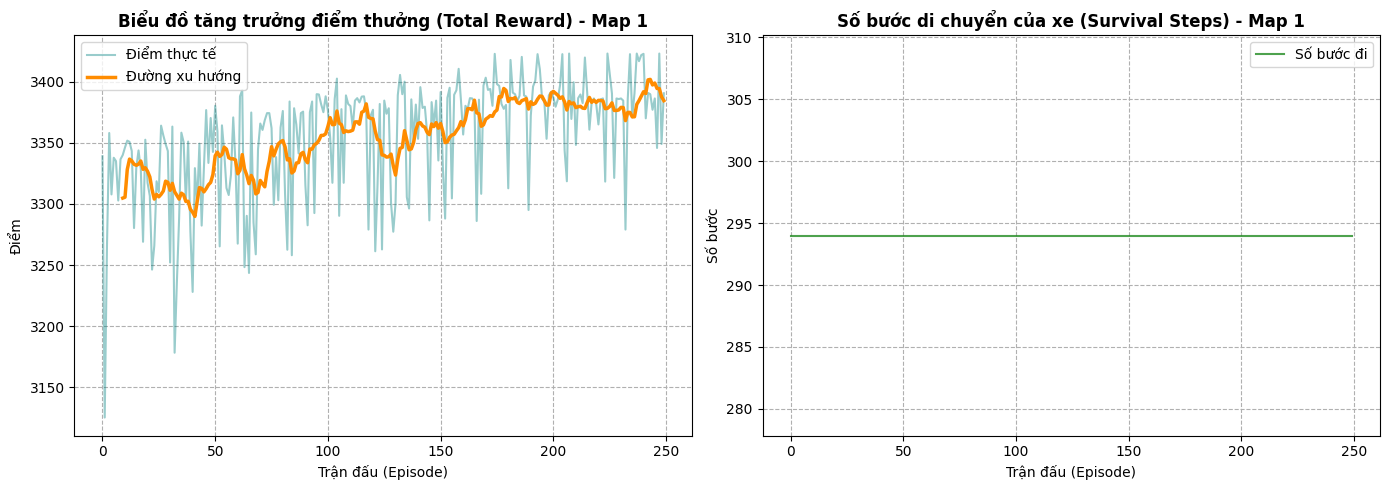

🎉 Đã xuất thành công biểu đồ 'horizontal_training_report_map1.png' cho MAP 1!
🎬 KẾT QUẢ XE DI CHUYỂN BÁM LÀN DƯỚI VÀ CÁN ĐÍCH Ở TRẬN 250 (MAP 1):


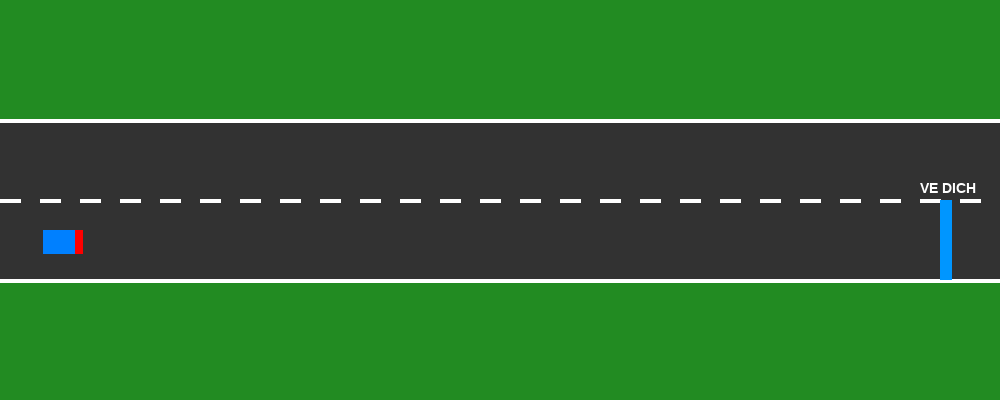

Đang chuyển đổi horizontal_map1_episode_250.gif sang horizontal_map1_episode_250.mp4...


Đã tạo thành công video MP4: horizontal_map1_episode_250.mp4

BẮT ĐẦU HUẤN LUYỆN CHO MAP 2: ĐƯỜNG CONG

--- ĐANG HUẤN LUYỆN XE CHẠY NGANG TRÊN MAP 2 (250 TRẬN) ---
-> Trận   1: DAM LE   | Điểm:  441.1 | File: horizontal_map2_episode_1.gif
-> Trận 100: VE DICH  | Điểm: 3255.6 | File: horizontal_map2_episode_100.gif
-> Trận 250: VE DICH  | Điểm: 3311.4 | File: horizontal_map2_episode_250.gif

Huấn luyện MAP 2 kết thúc thành công!


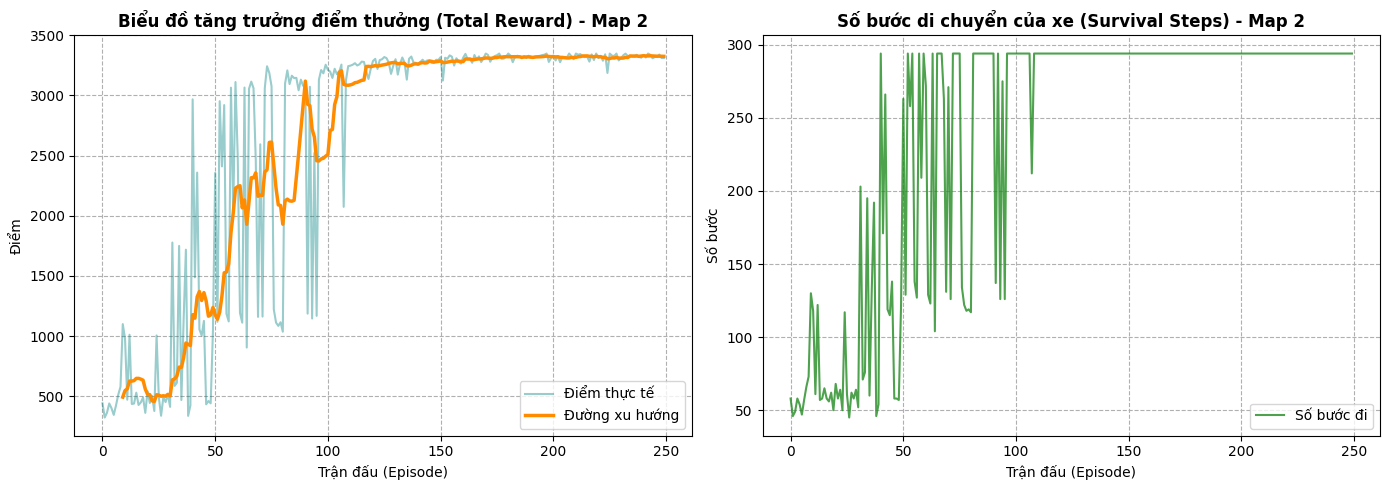

🎉 Đã xuất thành công biểu đồ 'horizontal_training_report_map2.png' cho MAP 2!
🎬 KẾT QUẢ XE DI CHUYỂN BÁM LÀN DƯỚI VÀ CÁN ĐÍCH Ở TRẬN 250 (MAP 2):


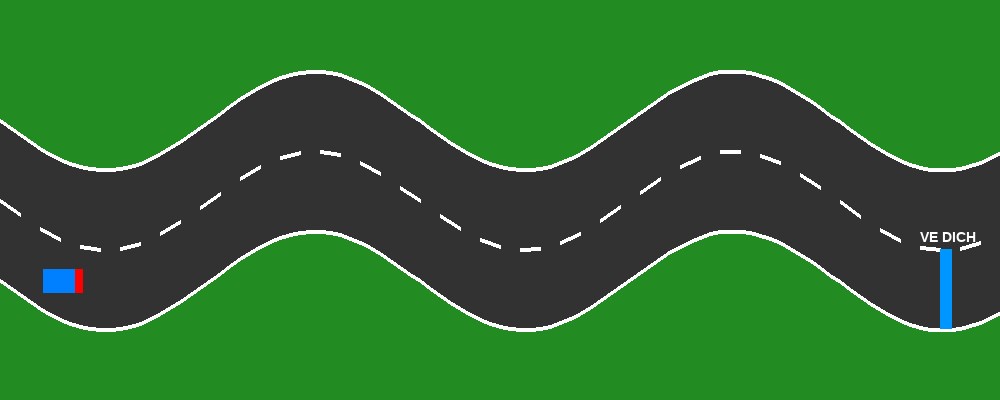

Đang chuyển đổi horizontal_map2_episode_250.gif sang horizontal_map2_episode_250.mp4...


Đã tạo thành công video MP4: horizontal_map2_episode_250.mp4

Quá trình huấn luyện và báo cáo cho cả hai bản đồ đã hoàn tất!


In [52]:
pygame.init()
virtual_screen = pygame.Surface((SCREEN_WIDTH, SCREEN_HEIGHT))

# Run for Map 1 (Straight Road)
print("\n======================================================")
print("BẮT ĐẦU HUẤN LUYỆN CHO MAP 1: ĐƯỜNG THẲNG")
print("======================================================")
history_rewards_map1, history_steps_map1 = train_and_save_results(1, virtual_screen)
generate_and_display_plots(1, history_rewards_map1, history_steps_map1)

gif_path_map1 = f"horizontal_map1_episode_250.gif"
mp4_path_map1 = f"horizontal_map1_episode_250.mp4"

if os.path.exists(gif_path_map1):
    print(f"🎬 KẾT QUẢ XE DI CHUYỂN BÁM LÀN DƯỚI VÀ CÁN ĐÍCH Ở TRẬN 250 (MAP 1):")
    display(Image(open(gif_path_map1, 'rb').read(), width=450))
    # Convert GIF to MP4
    print(f"Đang chuyển đổi {gif_path_map1} sang {mp4_path_map1}...")
    try:
        frames = imageio.mimread(gif_path_map1, memtest=False) # Changed memtest=True to memtest=False
        imageio.mimsave(mp4_path_map1, frames, fps=30)
        print(f"Đã tạo thành công video MP4: {mp4_path_map1}")
    except Exception as e:
        print(f"Lỗi khi chuyển đổi GIF sang MP4 cho Map 1: {e}")
else:
    print(f"Không tìm thấy file {gif_path_map1}. Vui lòng kiểm tra lại quá trình huấn luyện.")

# Run for Map 2 (Curved Road)
print("\n======================================================")
print("BẮT ĐẦU HUẤN LUYỆN CHO MAP 2: ĐƯỜNG CONG")
print("======================================================")
history_rewards_map2, history_steps_map2 = train_and_save_results(2, virtual_screen)
generate_and_display_plots(2, history_rewards_map2, history_steps_map2)

gif_path_map2 = f"horizontal_map2_episode_250.gif"
mp4_path_map2 = f"horizontal_map2_episode_250.mp4"

if os.path.exists(gif_path_map2):
    print(f"🎬 KẾT QUẢ XE DI CHUYỂN BÁM LÀN DƯỚI VÀ CÁN ĐÍCH Ở TRẬN 250 (MAP 2):")
    display(Image(open(gif_path_map2, 'rb').read(), width=450))
    # Convert GIF to MP4
    print(f"Đang chuyển đổi {gif_path_map2} sang {mp4_path_map2}...")
    try:
        frames = imageio.mimread(gif_path_map2, memtest=False) # Changed memtest=True to memtest=False
        imageio.mimsave(mp4_path_map2, frames, fps=30)
        print(f"Đã tạo thành công video MP4: {mp4_path_map2}")
    except Exception as e:
        print(f"Lỗi khi chuyển đổi GIF sang MP4 cho Map 2: {e}")
else:
    print(f"Không tìm thấy file {gif_path_map2}. Vui lòng kiểm tra lại quá trình huấn luyện.")

print("\nQuá trình huấn luyện và báo cáo cho cả hai bản đồ đã hoàn tất!")
